# Import Libraries

In [ ]:
# ==========================================
# SYSTEM & CORE UTILITIES
# ==========================================
import os
import ast
from collections import Counter

import numpy as np
import pandas as pd

# ==========================================
# PYTORCH (DEEP LEARNING)
# ==========================================
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# GOOGLE COLAB
# ==========================================
from google.colab import drive

# ==========================================
# NLP & TOKENIZATION
# ==========================================
import nltk
from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer, AutoModel

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')

# ==========================================
# MACHINE LEARNING (SKLEARN)
# ==========================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ==========================================
# SEQUENCE PROCESSING
# ==========================================
from keras.utils import pad_sequences

# ==========================================
# VISUALIZATION & PROGRESS
# ==========================================
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Read Cleaned Data
Data extracted and went through the data cleaning file. Look at Data_Clean.ipynb for the process.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the path based on your script
file_path = '/content/drive/MyDrive/BT4222 Project/Data/Court_Cases.csv'

try:
    # Load the CSV
    # Added encoding='utf-8-sig' to handle potential special characters in legal text
    df = pd.read_csv(file_path, encoding='utf-8-sig')

    print(f"Successfully loaded {len(df)} rows.")

    # Display first few rows to verify headers
    display(df.head())

except Exception as e:
    print(f"Error loading CSV: {e}")

Successfully loaded 358 rows.


,Case_Number,Coram,Judge,Date,Tribunal_Court,Plaintiff_Name,Defendant_Name,Combined_Facts,Issue,Rule,Application,Plaintiff_Label,Defendant_Label
0,CA 206/1999 (Counterclaim),Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Gan Boon Hock,Kea Resources Pte Ltd,"[{'Fact_Type': 'CONTRACT_EVENT', 'Fact_Date': ...",Whether an employee is entitled to claim unpai...,An employee may claim financial entitlements i...,He was owed financial entitlements as per his ...,Claim Allowed,Liable
1,CA 206/1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-03,Court of Appeal,Kea Holdings Pte Ltd,Gan Boon Hock,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a director can be held legally respons...,A director must act in the best interests of t...,Gan diverted business and misrepresented sale ...,Claim Allowed In-part,Liable
2,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai Property Marketing Pte Ltd,Low Hua Kin,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a subsidiary company can hold its dire...,A director is legally responsible for losses i...,The Plaintiff stated that it was used as a mer...,Claim Allowed,Liable
3,Civil Appeal No 124 of 1999,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ,2000-07-28,Court of Appeal,Kumagai-Zenecon Construction Pte Ltd (in liqui...,Low Hua Kin,"[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '198...",Whether a joint venture company can recover lo...,A director’s duty to the parent company extend...,The Plaintiff stated that the director’s unaut...,Claim Allowed,Liable
4,Suit 1032/1999,Kan Ting Chiu J,Kan Ting Chiu,2000-08-26,High Court of Singapore,Jurong Readymix Concrete Pte Ltd,Chng Heng Tiu,"[{'Fact_Type': 'CORPORATE_ROLE', 'Fact_Date': ...",Whether a corporate guarantor is liable for un...,A guarantee is enforceable if supported by val...,A concrete supplier increased a contractor's c...,Claim Allowed,Liable


In [ ]:
label_mapping = {
    "Not Liable": 0,
    "Liable": 1
}

# Create the target integer column on the entire dataset
df['target'] = df['Defendant_Label'].map(label_mapping)

# Drop any rows where the label couldn't be mapped (NaNs)
df = df.dropna(subset=['target']).reset_index(drop=True)
df['target'] = df['target'].astype(int)

# Data Preparation

## The 3D Matrix for HAN

Unlike standard Transformer models that process text as a single, flat sequence of tokens, a Hierarchical Attention Network (HAN) requires data structured in a way that mirrors the natural composition of documents: **Words form Facts, and Facts form Cases.**

This function (`preprocess_aligned_facts_to_3d`) constructs this hierarchical architecture:
1. **Matrix Initialization:** It initializes a 3D Numpy array with the shape `(Total_Documents, Max_Facts_Per_Doc, Max_Words_Per_Fact)`.
2. **Padding:** The array is pre-filled with the tokenizer's specific padding token ID to ensure uniform tensor shapes across batches.
3. **Fact-Level Tokenization:** It iterates through the dataset, extracting facts up to the `max_facts` limit (50) and tokenizing each individual fact up to the `max_words` limit (70).
4. **Coordinate Mapping:** Each token ID is placed into its exact `[document_index, fact_index, word_index]` coordinate within the 3D matrix.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")
VOCAB_SIZE = tokenizer.vocab_size

print(f"Tokenizer loaded successfully! Vocabulary size: {VOCAB_SIZE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded successfully! Vocabulary size: 30522


In [ ]:
def preprocess_aligned_facts_to_3d(fact_lists, tokenizer, max_facts=50, max_words=70):
    """
    Reads the original List of Dictionaries and perfectly aligns the text
    dimension with your MAX_FACTS and MAX_WORDS based on 95 percentile of dataset
    """
    num_docs = len(fact_lists)

    # Initialize 3D matrix (Docs x Facts x Words)
    data_3d = np.full(
        (num_docs, max_facts, max_words),
        fill_value=tokenizer.pad_token_id,
        dtype=np.int32
    )

    for doc_idx, fact_list in enumerate(fact_lists):
        # Handle stringified lists if necessary
        if isinstance(fact_list, str):
            try:
                fact_list = ast.literal_eval(fact_list)
            except:
                fact_list = []

        if not isinstance(fact_list, list):
            continue

        # Iterate through up to 50 facts
        for fact_idx, fact in enumerate(fact_list[:max_facts]):
            # Extract just the text for this specific fact
            text = str(fact.get('Text', ''))
            if not text.strip():
                continue

            # Tokenize this specific fact's text
            token_ids = tokenizer.encode(
                text,
                add_special_tokens=False,
                truncation=True,
                max_length=max_words
            )

            # Insert into the 3D matrix aligned to fact_idx
            for word_idx, token_id in enumerate(token_ids):
                data_3d[doc_idx, fact_idx, word_idx] = token_id

    return data_3d

## Tokenizing Legal Texts for BERT

Before feeding our text columns (`Issue` and `Rule`) into the neural network, we must translate them from raw strings into a numerical format that BERT can process (Token IDs).

This block utilizes the pre-trained tokenizer to process our text columns in bulk:
1. **Standardized Length (`max_length=128`):** We force every text snippet into a uniform mathematical shape of 128 dimensions.
2. **Truncation & Padding:** If a text is too long, it is automatically cut off at 128 tokens. If it is too short, it is padded with empty zeros (`pad_token_id`) until it reaches exactly 128. This uniformity is strictly required for deep learning matrix multiplication.
3. **DataFrame Integration:** By converting the resulting 2D Numpy matrix back into a list of 1D arrays, we can neatly insert these high-dimensional vectors directly into new columns in our Pandas DataFrame (`issue_vec` and `rule_vec`).

In [ ]:
def encode_strings_for_bert(texts, tokenizer, max_length=128):
    """
    Converts a list of strings into a list of token ID arrays.
    """
    encoded = tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='np'
    )
    # Convert the 2D array into a list of 1D arrays for easy DF assignment
    return list(encoded['input_ids'])

print("Encoding Issue and Rule columns...")

# Assign directly to new DataFrame columns
df['issue_vec'] = encode_strings_for_bert(df['Issue'].astype(str), tokenizer)
df['rule_vec'] = encode_strings_for_bert(df['Rule'].astype(str), tokenizer)

print(f"Issue Vector Column Head:\n{df['issue_vec'].head()}")
print(f"Rule Vector Column Head:\n{df['rule_vec'].head()}")

Encoding Issue and Rule columns...
Issue Vector Column Head:
0    [101, 331, 237, 533, 223, 575, 211, 388, 2071,...
1    [101, 331, 145, 921, 356, 219, 545, 2358, 939,...
2    [101, 331, 145, 734, 243, 356, 1231, 239, 921,...
3    [101, 331, 145, 857, 2168, 243, 356, 2443, 139...
4    [101, 331, 145, 1215, 977, 223, 1311, 217, 207...
Name: issue_vec, dtype: object
Rule Vector Column Head:
0    [101, 237, 533, 245, 388, 365, 6079, 253, 335,...
1    [101, 145, 921, 311, 325, 213, 207, 1432, 695,...
2    [101, 145, 921, 223, 2358, 939, 217, 1397, 796...
3    [101, 145, 921, 100, 163, 838, 211, 207, 776, ...
4    [101, 145, 1021, 223, 1938, 253, 2536, 218, 11...
Name: rule_vec, dtype: object


In [ ]:
court_encoder = LabelEncoder()
judge_encoder = LabelEncoder()

df['Court_Idx'] = court_encoder.fit_transform(df['Tribunal_Court'].astype(str))
df['Judge_Idx'] = judge_encoder.fit_transform(df['Judge'].astype(str))


print(court_encoder.classes_)
print(judge_encoder.classes_)

['Appellate Division of the High Court of Singapore' 'Court of Appeal'
 'General Division of the High Court'
 'General Division of the High Court of Singapore'
 'High Court of Singapore' 'Singapore International Commercial Court']
['Aedit Abdullah' 'Andre Maniam J' 'Andrew Ang' 'Andrew Ang J'
 'Andrew Phang Boon Leong JA' 'Andrew Phang Boon Leong JCA'
 'Ang Cheng Hock' 'Ang Cheng Hock J' 'Audrey Lim J' 'Audrey Lim JC'
 'Belinda Ang Saw Ean' 'Belinda Ang Saw Ean J' 'Chan Sek Keong CJ'
 'Chan Seng Onn' 'Chan Seng Onn J' 'Chao Hick Tin JA'
 'Chao Hick Tin JA; L P Thean JA; Yong Pung How CJ' 'Choo Han Teck J'
 'Chua Lee Ming' 'Chua Lee Ming J' 'Edmund Leow JC' 'G P Selvam'
 'George Wei' 'Hoo Sheau Peng' 'Hoo Sheau Peng J' 'Hri Kumar Nair'
 'Hri Kumar Nair J' 'Judith Prakash' 'Judith Prakash J'
 'Judith Prakash JA' 'Judith Prakash JCA' 'Kan Ting Chiu'
 'Kan Ting Chiu J' 'Kannan Ramesh' 'Kannan Ramesh J' 'Kannan Ramesh JAD'
 'Kristy Tan JC' 'Kwek Mean Luck' 'Kwek Mean Luck J' 'Lai Kew Chai J

## Aligning Types and Dates

To give the Hierarchical Attention Network (HAN) complete contextual awareness, we must process the metadata associated with each fact (Type and Date) so it perfectly aligns with our 50-fact textual sequence.

**1. Fact Type Encoding:**
Neural networks require numerical inputs. We extract the categorical `Fact_Type` for each fact and utilize a `LabelEncoder` to map every unique category to a specific integer ID. We then apply `pad_sequences` to ensure every case has a length of exactly `MAX_FACTS` (50), appending a specific `<PAD>` ID to fill any empty slots.

**2. Temporal Processing (Dates):**
Raw date strings are incompatible with deep learning layers. We extract the `Fact_Date` and convert it to the numerical "Day of the Year" (1-365). Missing or invalid dates are assigned a value of `0`. Finally, we pad these date sequences to a length of 50 using `0` as the padding value.

In [ ]:
# 1. The robust extraction function
def extract_all_fact_types(fact_input):
    if isinstance(fact_input, str):
        try:
            fact_list = ast.literal_eval(fact_input)
        except Exception:
            return ['Unknown']
    else:
        fact_list = fact_input

    if isinstance(fact_list, list) and len(fact_list) > 0:
        return [str(fact.get('Fact_Type', 'Unknown')) for fact in fact_list]

    return ['Unknown']

print("1. Extracting facts...")
df['All_Fact_Types'] = df['Combined_Facts'].apply(extract_all_fact_types)

# Let's prove it worked on the dataframe before encoding
print(f"Proof (Row 0): {df['All_Fact_Types'].iloc[0]}")

# 2. Gather all unique types
print("\n2. Building Vocabulary...")
all_unique_types = [fact for sublist in df['All_Fact_Types'] for fact in sublist]

type_encoder = LabelEncoder()
type_encoder.fit(list(set(all_unique_types)) + ['<PAD>'])

print(f"Categories found: {type_encoder.classes_}")

# 3. Convert to numbers
print("\n3. Converting words to numbers...")
df['Fact_Type_Seqs'] = df['All_Fact_Types'].apply(lambda x: type_encoder.transform(x).tolist())

# 4. Pad the sequences
print("4. Padding sequences...")
MAX_FACTS = 50
pad_id = type_encoder.transform(['<PAD>'])[0]

df['Fact_Type_Padded'] = pad_sequences(
    df['Fact_Type_Seqs'],
    maxlen=MAX_FACTS,
    padding='post',
    value=pad_id
).tolist()

print("\n All done! Example of final padded row:")
print(df['Fact_Type_Padded'].iloc[0][:15])

1. Extracting facts...
Proof (Row 0): ['CONTRACT_EVENT', 'CORPORATE_ROLE', 'CORPORATE_ROLE', 'CORPORATE_ROLE']

2. Building Vocabulary...
Categories found: ['<PAD>' 'AUTHORITY_EVENT' 'BOARD_ACTION' 'CHRONOLOGY' 'COMMUNICATION'
 'CONDUCT' 'CONTRACT_EVENT' 'CORPORATE_ROLE' 'DISCLOSURE_EVENT' 'DOCUMENT'
 'FINANCIAL_EVENT' 'PARTY_INFO' 'RELATED_PARTY_EVENT' 'RELATIONSHIP']

3. Converting words to numbers...
4. Padding sequences...

 All done! Example of final padded row:
[6, 7, 7, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
# 1. Extract and convert dates to integers (Day of Year)
def extract_all_fact_dates(fact_list):
    if isinstance(fact_list, list) and len(fact_list) > 0:
        dates = []
        for fact in fact_list:
            d_str = fact.get('Fact_Date', '')
            try:
                # Convert valid dates to day of year (1-365)
                dt = pd.to_datetime(d_str)
                dates.append(dt.dayofyear)
            except:
                # If date is missing/invalid, use 0
                dates.append(0)
        return dates
    return [0]

print("Extracting full sequence of Fact Dates...")
df['All_Fact_Dates'] = df['Combined_Facts'].apply(extract_all_fact_dates)

# 2. Pad the dates to EXACTLY match the Fact_Types length (MAX_FACTS = 50)
# We use 0 as the padding value for dates
df['Fact_Date_Padded'] = pad_sequences(
    df['All_Fact_Dates'],
    maxlen=MAX_FACTS,
    padding='post',
    value=0
).tolist()

print("Fact Dates successfully extracted and padded!")

Extracting full sequence of Fact Dates...
Fact Dates successfully extracted and padded!


## Train / Val / Test Split

Data needs to be split based on:
*   Temporal Sequence
*   Case_Number



In [ ]:
# Ensure Date is datetime type for sorting
df['Date'] = pd.to_datetime(df['Date'])

# Group by Case_Number to find the earliest date per case, then sort
cases = df.groupby('Case_Number')['Date'].min().sort_values().reset_index()

# Calculate split indices (70% Train, 15% Val, 15% Test)
n_cases = len(cases)
train_end = int(n_cases * 0.7)
val_end = int(n_cases * 0.85)

# Extract the Case_Numbers for each split
train_case_ids = cases.iloc[:train_end]['Case_Number']
val_case_ids = cases.iloc[train_end:val_end]['Case_Number']
test_case_ids = cases.iloc[val_end:]['Case_Number']

# Map the isolated Case_Numbers back to the main DataFrame
# Using .copy() prevents SettingWithCopy warnings later
train_df = df[df['Case_Number'].isin(train_case_ids)].copy()
val_df = df[df['Case_Number'].isin(val_case_ids)].copy()
test_df = df[df['Case_Number'].isin(test_case_ids)].copy()

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")

Train: 254 rows | Val: 32 rows | Test: 72 rows


## PyTorch Dataset Integration for HAN

Unlike standard text classifiers that only accept a single sequence of tokens, our Hierarchical Attention Network is a multi-modal architecture. It requires the simultaneous ingestion of 3D text matrices, contextual metadata sequences, and global document vectors.

This custom `LegalHANDataset` orchestrates this complex data pipeline:
1. **Tensor Conversion:** Upon initialization, it converts all disparate Numpy arrays (Words, Types, Dates, Issues, Rules, Court Indices, and Labels) into optimized PyTorch Tensors (`torch.long` for categorical/token inputs, `torch.float32` for binary labels).
2. **Label Reshaping:** It applies `.unsqueeze(1)` to the target labels, ensuring the dimensions strictly align with the requirements of the `BCEWithLogitsLoss` function used in binary classification.
3. **Synchronized Slicing:** The `__getitem__` method acts as a synchronized data courier. When queried by the DataLoader for a specific batch index, it slices perfectly horizontally across all input tensors, packaging the complete 'case file' into a unified dictionary for the model's forward pass.

In [ ]:
class LegalHANDataset(Dataset):
    def __init__(self, words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx, labels):
        # All inputs should be numpy arrays or lists of equal length
        self.words_3d = torch.tensor(words_3d, dtype=torch.long)
        self.fact_types = torch.tensor(fact_types, dtype=torch.long)
        self.fact_dates = torch.tensor(fact_dates, dtype=torch.long)

        self.issue_vec = torch.tensor(issue_vec, dtype=torch.long)
        self.rule_vec = torch.tensor(rule_vec, dtype=torch.long)

        self.court_idx = torch.tensor(court_idx, dtype=torch.long)
        self.judge_idx = torch.tensor(judge_idx, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'words_3d': self.words_3d[idx],
            'fact_types': self.fact_types[idx],
            'fact_dates': self.fact_dates[idx],
            'issue_vec': self.issue_vec[idx],
            'rule_vec': self.rule_vec[idx],
            'court_idx': self.court_idx[idx],
            'judge_idx': self.judge_idx[idx],
            'label': self.labels[idx]
        }

In [ ]:
print("Converting aligned fact dictionaries to 3D BERT matrices...")

# Notice we pass the 'Combined_Facts' (the dictionaries)
# MAX_FACTS must be 50 to exactly match your padded types and dates
X_train_3d = preprocess_aligned_facts_to_3d(train_df['Combined_Facts'].tolist(), tokenizer, max_facts=50)
X_val_3d = preprocess_aligned_facts_to_3d(val_df['Combined_Facts'].tolist(), tokenizer, max_facts=50)
X_test_3d = preprocess_aligned_facts_to_3d(test_df['Combined_Facts'].tolist(), tokenizer, max_facts=50)

# Expected Shape: (num_cases, 50 facts, 70 words)
print(f"Train 3D Shape: {X_train_3d.shape}")

Converting aligned fact dictionaries to 3D BERT matrices...
Train 3D Shape: (254, 50, 70)


## DataLoaders: Batching the Data

To train the Hierarchical Attention Network efficiently, we wrap our custom `LegalHANDataset` instances within PyTorch `DataLoaders`. The DataLoader acts as an optimized iterator, handling batching and memory management during the training loop.

* **List Conversion:** We explicitly convert Pandas DataFrame columns to Python lists (`.tolist()`) before instantiating the dataset to ensure clean Tensor conversion and prevent memory referencing errors.
* **Batch Size (16):** We pass the data to the model in mini-batches of 16 cases. This optimizes GPU memory usage while providing a stable gradient for the model to update its weights.
* **Shuffling:**  `train_loader`, `val_loader` & `test_loader`: Kept at `shuffle=False`

In [ ]:
from torch.utils.data import DataLoader

# 1. Training Dataset and DataLoader
# Initialize Dataset (Notice the .tolist() on the array/list columns!)
train_dataset = LegalHANDataset(
    words_3d = X_train_3d,
    fact_types = train_df['Fact_Type_Padded'].tolist(),
    fact_dates = train_df['Fact_Date_Padded'].tolist(),
    issue_vec = train_df['issue_vec'].tolist(),
    rule_vec = train_df['rule_vec'].tolist(),
    court_idx = train_df['Court_Idx'].tolist(),
    judge_idx = train_df['Judge_Idx'].tolist(),
    labels = train_df['target'].tolist()
)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

# 2. Validation Dataset and DataLoader
val_dataset = LegalHANDataset(
    words_3d = X_val_3d,
    fact_types = val_df['Fact_Type_Padded'].tolist(),
    fact_dates = val_df['Fact_Date_Padded'].tolist(),
    issue_vec = val_df['issue_vec'].tolist(),
    rule_vec = val_df['rule_vec'].tolist(),
    court_idx = val_df['Court_Idx'].tolist(),
    judge_idx = train_df['Judge_Idx'].tolist(),
    labels = val_df['target'].tolist()
)

# Shuffle=False for consistent evaluation
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# 3. Test Dataset and DataLoader
test_dataset = LegalHANDataset(
    words_3d = X_test_3d,
    fact_types = test_df['Fact_Type_Padded'].tolist(),
    fact_dates = test_df['Fact_Date_Padded'].tolist(),
    issue_vec = test_df['issue_vec'].tolist(),
    rule_vec = test_df['rule_vec'].tolist(),
    court_idx = test_df['Court_Idx'].tolist(),
    judge_idx = train_df['Judge_Idx'].tolist(),
    labels = test_df['target'].tolist()
)

# Shuffle=False for consistent evaluation
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"DataLoaders Ready! Train: {len(train_loader)} batches, Val: {len(val_loader)} batches, Test: {len(test_loader)} batches")

DataLoaders Ready! Train: 16 batches, Val: 2 batches, Test: 5 batches


/tmp/ipykernel_4707/2449536793.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.issue_vec = torch.tensor(issue_vec, dtype=torch.long)


# Word-level Attention Network
The first computational layer of the Hierarchical Attention Network focuses on the lowest level of our text hierarchy: Words. The goal of this `WordAttentionEncoder` is to read a sequence of tokens and compress them into a single, dense "Fact Vector."

1. **Word Embeddings:** Token IDs are converted into 768-dimensional dense vectors.
2. **Bi-Directional Context (Bi-GRU):** The sequence is processed both forward and backward using a 2-layer Bi-GRU. This ensures that the mathematical representation of each word contains the semantic context of the words surrounding it.
3. **Word-Level Attention:** Not all words contribute equally to legal meaning. An MLP calculates an attention score for each word, normalized via Softmax. Words like "negligence" receive high weights, while stop words like "the" receive low weights.
4. **Context Vector Aggregation:** The GRU outputs are multiplied by their respective attention weights and summed. This operation squashes the temporal word dimension, reducing the entire sentence down to a single 128-dimensional Fact Vector. A final `LayerNorm` is applied to stabilize the gradients for downstream processing.

In [ ]:
class WordAttentionEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=768, gru_hidden=64):
        super(WordAttentionEncoder, self).__init__()

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # 2. Word Encoder: 2x Bi-GRU Layers (768 dims per token -> 64 forward, 64 backward)
        self.word_gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        # 3. Word Attention Mechanism (MLP)
        # gru_hidden * 2 because of bidirectional
        self.word_attention = nn.Sequential(
            nn.Linear(gru_hidden * 2, gru_hidden * 2),
            nn.Tanh(),
            nn.Linear(gru_hidden * 2, 1) # Outputs attention scores
        )

        self.layer_norm = nn.LayerNorm(gru_hidden * 2)

    def forward(self, words):
        # words shape: (batch_size * num_sentences, num_words)
        x = self.embedding(words)

        # GRU Output shape: (batch_size * num_sentences, num_words, 128)
        gru_out, _ = self.word_gru(x)

        # Attention Weights
        attn_scores = self.word_attention(gru_out).squeeze(2) # (batch*sentences, words)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(2) # (batch*sentences, words, 1)

        # Context Vector (Weighted Sum)
        # Shape: (batch_size * num_sentences, 128)
        sentence_vector = torch.sum(gru_out * attn_weights, dim=1)

        # Add + Norm (as specified in your diagram)
        sentence_vector = self.layer_norm(sentence_vector)

        return sentence_vector

# Sentence-Level Attention Network
The second computational layer of the Hierarchical Attention Network focuses on the macro-level of our text hierarchy: Facts and the Document timeline. The goal of the `SentenceAttentionEncoder` is to read the sequence of Fact Vectors, inject their contextual metadata, and compress the entire case into a single Document Vector.

1. **Metadata Concatenation:** The 128-dimensional textual Fact Vector is concatenated with its corresponding Fact Type embedding and Fact Date embedding. This provides the model with complete context: *What* happened, *what kind* of event it was, and *when* it occurred.
2. **Chronological Context (Bi-GRU):** The sequence of facts is processed forward and backward through a Bi-GRU. This allows the model to understand the temporal and procedural flow of the lawsuit.
3. **Fact-Level Attention:** A secondary MLP calculates an attention score for each individual fact. This allows the model to heavily weight facts (e.g., an admission of guilt) while ignoring procedural boilerplate.
4. **Document Vector Aggregation:** The fact vectors are multiplied by their attention weights and summed. This operation squashes the temporal timeline dimension (up to 50 facts), reducing the entire case file down to a single, highly concentrated 128-dimensional Document Vector.

In [ ]:
class SentenceAttentionEncoder(nn.Module):
    def __init__(self, sentence_dim=128, type_dim=16, date_dim=16, gru_hidden=64):
        super(SentenceAttentionEncoder, self).__init__()

        # Input size is Sentence Vector + Fact Type Embed + Date Embed
        combined_input_dim = sentence_dim + type_dim + date_dim

        # 1. Sentence Encoder: 1-2x Bi-GRU Layers
        self.sentence_gru = nn.GRU(
            input_size=combined_input_dim,
            hidden_size=gru_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        # 2. Sentence Attention Mechanism
        self.sentence_attention = nn.Sequential(
            nn.Linear(gru_hidden * 2, gru_hidden * 2),
            nn.Tanh(),
            nn.Linear(gru_hidden * 2, 1)
        )

        self.layer_norm = nn.LayerNorm(gru_hidden * 2)

    def forward(self, sentence_vectors, fact_types, fact_dates):
        # sentence_vectors: (batch_size, num_sentences, 128)
        # fact_types/dates: (batch_size, num_sentences, dim)

        # Concatenate sentence meaning with its metadata
        x = torch.cat([sentence_vectors, fact_types, fact_dates], dim=2)

        # GRU Output shape: (batch_size, num_sentences, 128)
        gru_out, _ = self.sentence_gru(x)

        # Attention Weights
        attn_scores = self.sentence_attention(gru_out).squeeze(2)
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(2)

        # Document Vector (Weighted Sum of Sentences)
        # Shape: (batch_size, 128)
        doc_vector = torch.sum(gru_out * attn_weights, dim=1)
        doc_vector = self.layer_norm(doc_vector)

        return doc_vector

# HAN with Late Fusion

This block defines the overarching `HAN` module, which acts as the master orchestrator for the entire neural network. It employs a "Late Fusion" architecture to combine the chronological narrative of a case with its static global parameters.

1. **SwiGLU Activation:** We implement a custom Swish-Gated Linear Unit (SwiGLU) for the final classification head, mirroring state-of-the-art LLM architectures. This gating mechanism allows the network to dynamically filter out irrelevant features immediately prior to the final logit projection.
2. **The Timeline Pathway:** The model processes the 3D word matrix through the `WordAttentionEncoder` and `SentenceAttentionEncoder`, resulting in a 128-dimensional Document Vector that represents the chronological factual narrative.
3. **The Global Pathway:** The overarching Legal Issue and Rule of Law are processed through isolated, dedicated Bi-GRUs. The categorical Court ID is processed through an embedding layer.
4. **Late Fusion:** The network concatenates the Document Vector, Issue Vector, Rule Vector, and Court Embedding into a singular 400-dimensional global representation.
5. **Classification:** This fused representation is passed through a multi-layer perceptron to yield the final binary prediction (Liable vs. Not Liable).

In [ ]:
# Swish-Gated Linear Unit (SwiGLU) implementation
class SwiGLU(nn.Module):
    def forward(self, x):
        x, gate = x.chunk(2, dim=-1)
        return F.silu(gate) * x

In [ ]:
class LegalHAN(nn.Module):
    def __init__(self, vocab_size, num_fact_types, num_courts, num_judges):
        super(LegalHAN, self).__init__()

        # 1. Text Processors
        self.word_encoder = WordAttentionEncoder(vocab_size)

        # --- ALIGNED TO DIAGRAM: Restore Type (16) and Date (16) Dims ---
        self.sentence_encoder = SentenceAttentionEncoder(sentence_dim=128, type_dim=16, date_dim=16)

        # 2. Embeddings
        self.fact_type_embed = nn.Embedding(num_fact_types, 16)
        self.date_embed = nn.Embedding(367, 16, padding_idx=0)
        self.court_embed = nn.Embedding(num_courts, 16)

        # NEW: Added judge embedding (using 16 dimensions to match the court)
        self.judge_embed = nn.Embedding(num_judges, 16)

        self.text_embed = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.issue_gru = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.rule_gru = nn.GRU(128, 64, batch_first=True, bidirectional=True)

        # 3. Late Fusion Dimensions
        fusion_dim = 128 + 128 + 128 + 16 + 16

        # 4. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            SwiGLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 1)
        )

    def forward(self, words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx):
        batch_size, num_sentences, num_words = words_3d.shape

        # --- A. PROCESS THE WORDS ---
        words_2d = words_3d.view(-1, num_words)
        sent_vecs_2d = self.word_encoder(words_2d)
        sent_vecs_3d = sent_vecs_2d.view(batch_size, num_sentences, -1)

        # --- B. PROCESS METADATA ---
        types_emb = self.fact_type_embed(fact_types)
        dates_emb = self.date_embed(fact_dates)

        # --- C. DIAGRAM CONCATENATION (Text + Type + Date) ---
        text_doc_vec = self.sentence_encoder(sent_vecs_3d, types_emb, dates_emb)

        # --- D. PROCESS COURT, JUDGE, ISSUE, RULE ---
        court_emb = self.court_embed(court_idx)
        judge_emb = self.judge_embed(judge_idx)

        issue_embedded = self.text_embed(issue_vec)
        rule_embedded = self.text_embed(rule_vec)

        _, issue_hidden = self.issue_gru(issue_embedded)
        _, rule_hidden = self.rule_gru(rule_embedded)

        issue_final = torch.cat((issue_hidden[-2,:,:], issue_hidden[-1,:,:]), dim=1)
        rule_final = torch.cat((rule_hidden[-2,:,:], rule_hidden[-1,:,:]), dim=1)

        # --- E. LATE FUSION ---
        fused_vector = torch.cat([
            text_doc_vec,
            issue_final,
            rule_final,
            court_emb,
            judge_emb
        ], dim=1)

        # --- F. CLASSIFICATION ---
        logits = self.classifier(fused_vector)

        return logits

In [ ]:
print("Initializing Legal HAN...")

# 1. Define Model Dimensions based on your actual data
VOCAB_SIZE = tokenizer.vocab_size
NUM_FACT_TYPES = len(type_encoder.classes_)
NUM_COURTS = len(court_encoder.classes_)
NUM_JUDGES = len(judge_encoder.classes_)

# 2. Instantiate the model and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LegalHAN(
    vocab_size=VOCAB_SIZE,
    num_fact_types=NUM_FACT_TYPES,
    num_courts=NUM_COURTS,
    num_judges=NUM_JUDGES
).to(device)

# 3. Define Loss and Optimizer
# BCEWithLogitsLoss for binary classification
criterion = nn.BCEWithLogitsLoss()

# AdamW is the standard optimizer.
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

print("Model successfully initialized and ready for training!")

Initializing Legal HAN...
Model successfully initialized and ready for training!


In [ ]:
def evaluate_model(model, dataloader, criterion):
    model.eval() # Set to evaluation mode
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # Move all batch data to GPU
            words_3d = batch['words_3d'].to(device)
            fact_types = batch['fact_types'].to(device)
            fact_dates = batch['fact_dates'].to(device)
            issue_vec = batch['issue_vec'].to(device)
            rule_vec = batch['rule_vec'].to(device)
            court_idx = batch['court_idx'].to(device)
            judge_idx = batch['judge_idx'].to(device)
            labels = batch['label'].to(device)

            # Forward pass
            logits = model(words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            # Convert logits to 0 or 1 predictions using a Sigmoid threshold of 0.5
            preds = torch.sigmoid(logits) >= 0.5

            all_preds.extend(preds.cpu().numpy().astype(int))
            all_labels.extend(labels.cpu().numpy().astype(int))

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return avg_loss, acc, f1

--- Starting Training ---
Epoch 1/5 | Train Loss: 0.6991 | Val Loss: 0.7094 | Val Acc: 40.62% | Val F1: 0.00
Epoch 2/5 | Train Loss: 0.6867 | Val Loss: 0.6968 | Val Acc: 50.00% | Val F1: 0.47
Epoch 3/5 | Train Loss: 0.6819 | Val Loss: 0.6923 | Val Acc: 56.25% | Val F1: 0.70
Epoch 4/5 | Train Loss: 0.6775 | Val Loss: 0.6929 | Val Acc: 46.88% | Val F1: 0.60
Epoch 5/5 | Train Loss: 0.6620 | Val Loss: 0.6937 | Val Acc: 53.12% | Val F1: 0.68
--- Training Complete! ---


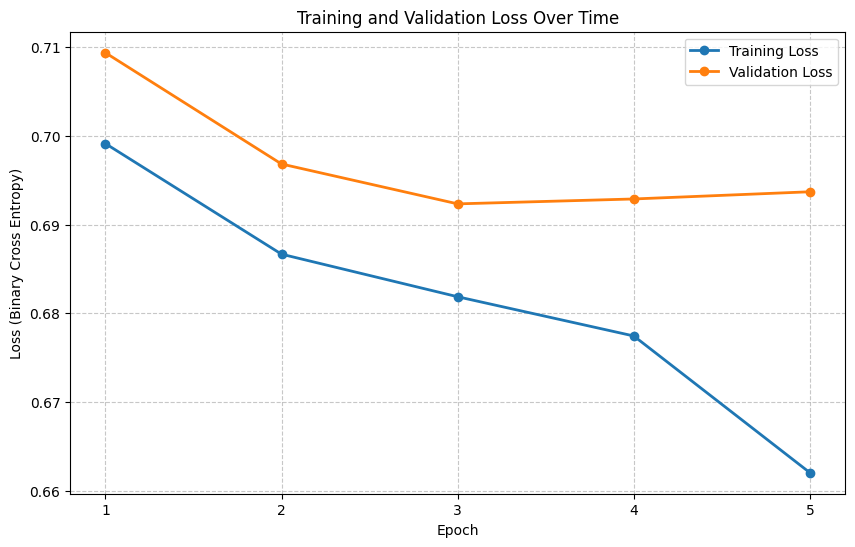

In [ ]:
EPOCHS = 5 #Adjusted to use optimal Epochs

# Initialize empty lists to keep track of the losses over time
history_train_loss = []
history_val_loss = []

print("--- Starting Training ---")

for epoch in range(EPOCHS):
    model.train() # Set to training mode
    total_train_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        # 1. Clear previous gradients
        optimizer.zero_grad()

        # 2. Move data to GPU
        words_3d = batch['words_3d'].to(device)
        fact_types = batch['fact_types'].to(device)
        fact_dates = batch['fact_dates'].to(device)
        issue_vec = batch['issue_vec'].to(device)
        rule_vec = batch['rule_vec'].to(device)
        court_idx = batch['court_idx'].to(device)
        judge_idx = batch['judge_idx'].to(device)
        labels = batch['label'].to(device)

        # 3. Forward Pass (Get Predictions)
        logits = model(words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx)

        # 4. Calculate Loss
        loss = criterion(logits, labels)
        total_train_loss += loss.item()

        # 5. Backward Pass (Calculate Gradients)
        loss.backward()

        # 6. Update Weights
        optimizer.step()

    # Calculate average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)

    # Evaluate on the validation set
    val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion)

    # NEW: Append this epoch's results to our tracking lists
    history_train_loss.append(avg_train_loss)
    history_val_loss.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc * 100:.2f}% | "
          f"Val F1: {val_f1:.2f}")

print("--- Training Complete! ---")

# PLOTTING THE LOSS CURVE
plt.figure(figsize=(10, 6))

# Plot the training and validation lines
plt.plot(range(1, EPOCHS + 1), history_train_loss, label='Training Loss', marker='o', linewidth=2)
plt.plot(range(1, EPOCHS + 1), history_val_loss, label='Validation Loss', marker='o', linewidth=2)

# Format the chart
plt.title('Training and Validation Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [ ]:
print("========================================")
print("       TRAINING SET HAN METRICS")
print("========================================")

# --- Generate predictions for the TRAINING set ---
model.eval()
all_train_preds = []
all_train_probs = []

with torch.no_grad(): # Saves memory, prevents weight updates
    for batch in train_loader:
        words_3d = batch['words_3d'].to(device)
        fact_types = batch['fact_types'].to(device)
        fact_dates = batch['fact_dates'].to(device)
        issue_vec = batch['issue_vec'].to(device)
        rule_vec = batch['rule_vec'].to(device)
        court_idx = batch['court_idx'].to(device)
        judge_idx = batch['judge_idx'].to(device)

        logits = model(words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx)
        probs = torch.sigmoid(logits)
        preds = probs >= 0.5

        # Ensure predictions and probabilities are flattened to single numbers
        all_train_probs.extend(probs.cpu().numpy().flatten().tolist())
        all_train_preds.extend(preds.cpu().numpy().flatten().tolist())

train_df['han_pred'] = all_train_preds
train_df['han_prob'] = all_train_probs # Attach probabilities to dataframe

# Aggregate Row-Level predictions to Case-Level using Majority Vote
han_case_eval_train = train_df.groupby('Case_Number').agg({
    'target': 'first',             # The true label
    'han_pred': lambda x: x.mode()[0], # Hard Prediction: Majority vote
    'han_prob': 'max'              # Probability: Highest risk defendant triggers the case
}).reset_index()

print(f"Aggregation complete. Processed {len(han_case_eval_train)} unique TRAINING cases.")


# --- 1. ROW-LEVEL METRICS (TRAINING) ---
row_true_train = train_df['target']
row_pred_train = train_df['han_pred']
row_prob_train = train_df['han_prob']

row_auc_train = roc_auc_score(row_true_train, row_prob_train)
row_acc_train = accuracy_score(row_true_train, row_pred_train)
row_prec_train = precision_score(row_true_train, row_pred_train, zero_division=0)
row_rec_train = recall_score(row_true_train, row_pred_train, zero_division=0)
row_f1_train = f1_score(row_true_train, row_pred_train, zero_division=0)

print("\n[ Row-Level Performance (TRAINING) ]")
print(f"ROC-AUC:   {row_auc_train:.4f}")
print(f"Accuracy:  {row_acc_train * 100:.2f}%")
print(f"Precision: {row_prec_train:.2f}")
print(f"Recall:    {row_rec_train:.2f}")
print(f"F1 Score:  {row_f1_train:.2f}")

# --- 2. CASE-LEVEL METRICS (TRAINING) ---
case_true_train = han_case_eval_train['target']
case_pred_train = han_case_eval_train['han_pred'].apply(lambda x: x[0] if isinstance(x, np.ndarray) else x)
case_prob_train = han_case_eval_train['han_prob']

case_auc_train = roc_auc_score(case_true_train, case_prob_train)
case_acc_train = accuracy_score(case_true_train, case_pred_train)
case_prec_train = precision_score(case_true_train, case_pred_train, zero_division=0)
case_rec_train = recall_score(case_true_train, case_pred_train, zero_division=0)
case_f1_train = f1_score(case_true_train, case_pred_train, zero_division=0)
print("\n[ Case-Level Performance (Majority Vote - TRAINING) ]")
print(f"ROC-AUC:   {case_auc_train:.4f}")
print(f"Accuracy:  {case_acc_train * 100:.2f}%")
print(f"Precision: {case_prec_train :.2f}")
print(f"Recall:    {case_rec_train:.2f}")
print(f"F1 Score:  {case_f1_train:.2f}")
print("========================================")

       TRAINING SET HAN METRICS
Aggregation complete. Processed 109 unique TRAINING cases.

[ Row-Level Performance (TRAINING) ]
ROC-AUC:   0.7757
Accuracy:  69.29%
Precision: 0.68
Recall:    0.70
F1 Score:  0.69

[ Case-Level Performance (Majority Vote - TRAINING) ]
ROC-AUC:   0.6717
Accuracy:  64.22%
Precision: 0.69
Recall:    0.74
F1 Score:  0.71


In [ ]:
print("========================================")
print("        FINAL HAN MODEL METRICS")
print("========================================")

# --- Generate predictions for the test set ---
model.eval()
all_test_preds = []
all_test_probs = []

with torch.no_grad():
    for batch in test_loader:
        words_3d = batch['words_3d'].to(device)
        fact_types = batch['fact_types'].to(device)
        fact_dates = batch['fact_dates'].to(device)
        issue_vec = batch['issue_vec'].to(device)
        rule_vec = batch['rule_vec'].to(device)
        court_idx = batch['court_idx'].to(device)
        judge_idx = batch['judge_idx'].to(device)

        logits = model(words_3d, fact_types, fact_dates, issue_vec, rule_vec, court_idx, judge_idx)

        probs = torch.sigmoid(logits)
        preds = probs >= 0.5

        # Ensure predictions and probabilities are flattened to single numbers
        all_test_probs.extend(probs.cpu().numpy().flatten().tolist())
        all_test_preds.extend(preds.cpu().numpy().flatten().tolist())

test_df['han_pred'] = all_test_preds
test_df['han_prob'] = all_test_probs # Attach probabilities to dataframe

# Aggregate Row-Level predictions to Case-Level using Majority Vote
# This must be run before the metrics/matrix code
han_case_eval = test_df.groupby('Case_Number').agg({
    'target': 'first',             # The true label
    'han_pred': lambda x: x.mode()[0], # Hard Prediction: Majority vote
    'han_prob': 'max'              # Probability: Highest risk defendant triggers the case
}).reset_index()

print(f"Aggregation complete. Processed {len(han_case_eval)} unique cases.")


# --- 1. ROW-LEVEL METRICS ---
row_true = test_df['target']
row_pred = test_df['han_pred']
row_prob = test_df['han_prob']

row_auc = roc_auc_score(row_true, row_prob)
row_acc = accuracy_score(row_true, row_pred)
row_prec = precision_score(row_true, row_pred, zero_division=0)
row_rec = recall_score(row_true, row_pred, zero_division=0)
row_f1 = f1_score(row_true, row_pred, zero_division=0)

print("\n[ Row-Level Performance ]")
print(f"ROC-AUC:   {row_auc:.4f}")
print(f"Accuracy:  {row_acc * 100:.2f}%")
print(f"Precision: {row_prec:.2f}")
print(f"Recall:    {row_rec:.2f}")
print(f"F1 Score:  {row_f1:.2f}")

# --- 2. CASE-LEVEL METRICS ---
case_true = han_case_eval['target']
case_pred = han_case_eval['han_pred'].apply(lambda x: x[0] if isinstance(x, np.ndarray) else x)
case_prob = han_case_eval['han_prob']

case_auc = roc_auc_score(case_true, case_prob)
case_acc = accuracy_score(case_true, case_pred)
case_prec = precision_score(case_true, case_pred, zero_division=0)
case_rec = recall_score(case_true, case_pred, zero_division=0)
case_f1 = f1_score(case_true, case_pred, zero_division=0)

print("\n[ Case-Level Performance (Majority Vote) ]")
print(f"ROC-AUC:   {case_auc:.4f}")
print(f"Accuracy:  {case_acc * 100:.2f}%")
print(f"Precision: {case_prec :.2f}")
print(f"Recall:    {case_rec:.2f}")
print(f"F1 Score:  {case_f1:.2f}")
print("========================================")

        FINAL HAN MODEL METRICS
Aggregation complete. Processed 24 unique cases.

[ Row-Level Performance ]
ROC-AUC:   0.4167
Accuracy:  61.11%
Precision: 0.65
Recall:    0.90
F1 Score:  0.75

[ Case-Level Performance (Majority Vote) ]
ROC-AUC:   0.5625
Accuracy:  50.00%
Precision: 0.60
Recall:    0.75
F1 Score:  0.67


--- ROW-LEVEL CONFUSION MATRIX (TRAINING SET) ---
                       Pred Not Liable (0)  Pred Liable (1)
Actual Not Liable (0)                   89               41
Actual Liable (1)                       37               87

--- CASE-LEVEL CONFUSION MATRIX (TRAINING SET) ---
                       Pred Not Liable (0)  Pred Liable (1)
Actual Not Liable (0)                   22               22
Actual Liable (1)                       17               48


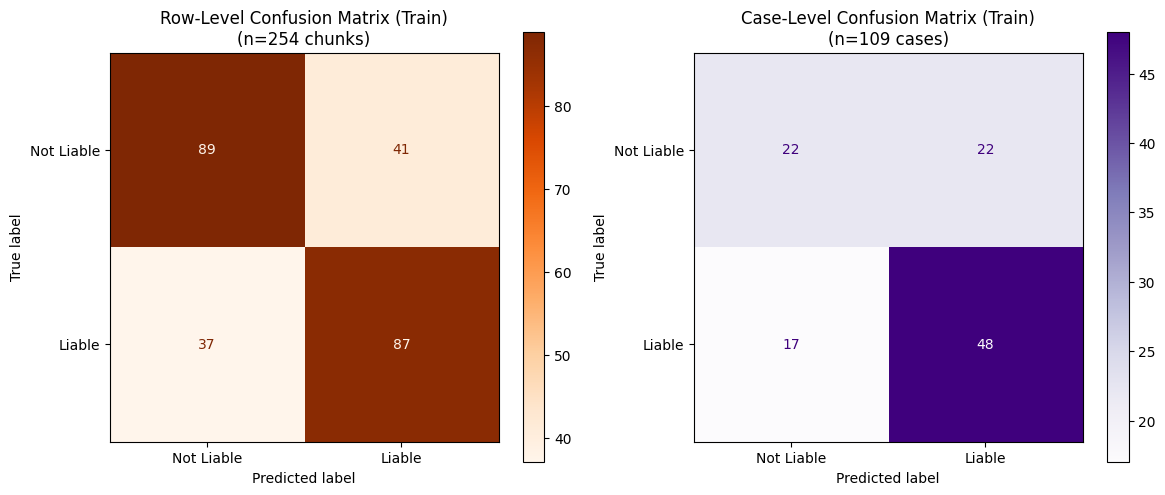

In [ ]:
# 1. Calculate the raw confusion matrices
# Using the perfectly formatted variables from your Training Metrics block
cm_row_train = confusion_matrix(row_true_train, row_pred_train)
cm_case_train = confusion_matrix(case_true_train, case_pred_train)

# 2. Print readable text versions
print("--- ROW-LEVEL CONFUSION MATRIX (TRAINING SET) ---")
print(pd.DataFrame(cm_row_train,
                   index=["Actual Not Liable (0)", "Actual Liable (1)"],
                   columns=["Pred Not Liable (0)", "Pred Liable (1)"]))

print("\n--- CASE-LEVEL CONFUSION MATRIX (TRAINING SET) ---")
print(pd.DataFrame(cm_case_train,
                   index=["Actual Not Liable (0)", "Actual Liable (1)"],
                   columns=["Pred Not Liable (0)", "Pred Liable (1)"]))

# 3. Plot beautiful side-by-side visual charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Row-Level (Oranges to distinguish from Test Set)
disp_row_train = ConfusionMatrixDisplay(confusion_matrix=cm_row_train, display_labels=["Not Liable", "Liable"])
disp_row_train.plot(cmap=plt.cm.Oranges, values_format='d', ax=axes[0])
axes[0].set_title(f"Row-Level Confusion Matrix (Train)\n(n={len(train_df)} chunks)")

# Plot Case-Level (Purples to distinguish from Test Set)
disp_case_train = ConfusionMatrixDisplay(confusion_matrix=cm_case_train, display_labels=["Not Liable", "Liable"])
disp_case_train.plot(cmap=plt.cm.Purples, values_format='d', ax=axes[1])
axes[1].set_title(f"Case-Level Confusion Matrix (Train)\n(n={len(han_case_eval_train)} cases)")

plt.tight_layout()
plt.show()

--- ROW-LEVEL CONFUSION MATRIX ---
                       Pred Not Liable (0)  Pred Liable (1)
Actual Not Liable (0)                    1               23
Actual Liable (1)                        5               43

--- CASE-LEVEL CONFUSION MATRIX ---
                       Pred Not Liable (0)  Pred Liable (1)
Actual Not Liable (0)                    0                8
Actual Liable (1)                        4               12


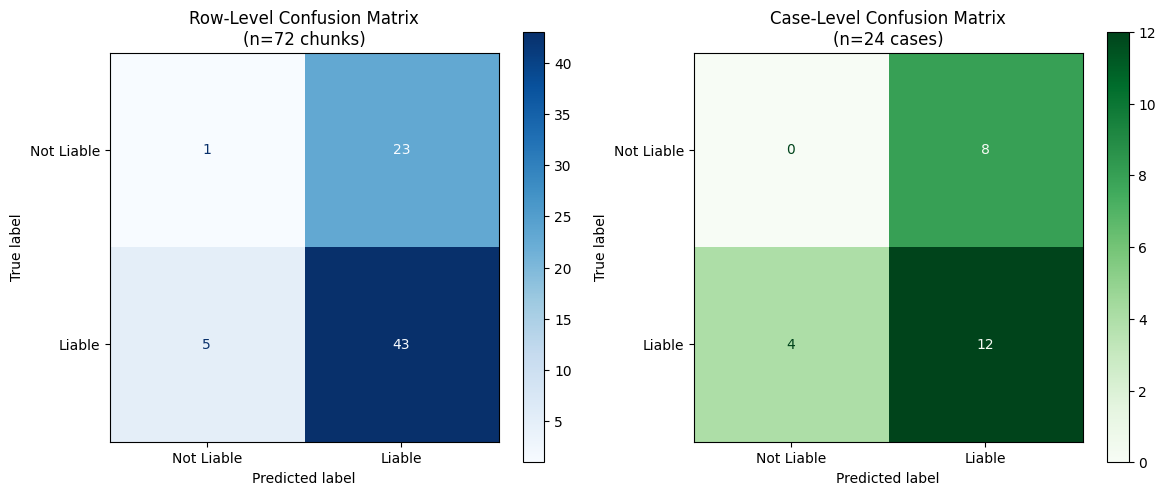

In [ ]:
# 1. Calculate the raw confusion matrices
cm_row = confusion_matrix(test_df['target'], test_df['han_pred'])
cm_case = confusion_matrix(han_case_eval['target'], han_case_eval['han_pred'])

# 2. Print readable text versions
print("--- ROW-LEVEL CONFUSION MATRIX ---")
print(pd.DataFrame(cm_row,
                   index=["Actual Not Liable (0)", "Actual Liable (1)"],
                   columns=["Pred Not Liable (0)", "Pred Liable (1)"]))

print("\n--- CASE-LEVEL CONFUSION MATRIX ---")
print(pd.DataFrame(cm_case,
                   index=["Actual Not Liable (0)", "Actual Liable (1)"],
                   columns=["Pred Not Liable (0)", "Pred Liable (1)"]))

# 3. Plot beautiful side-by-side visual charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Row-Level (Blue)
disp_row = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=["Not Liable", "Liable"])
disp_row.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[0])
axes[0].set_title(f"Row-Level Confusion Matrix\n(n={len(test_df)} chunks)")

# Plot Case-Level (Green)
disp_case = ConfusionMatrixDisplay(confusion_matrix=cm_case, display_labels=["Not Liable", "Liable"])
disp_case.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[1])
axes[1].set_title(f"Case-Level Confusion Matrix\n(n={len(han_case_eval)} cases)")

plt.tight_layout()
plt.show()

# Final Performance Evaluation: Hierarchical Attention Network (HAN)

This report evaluates the final performance of the Hierarchical Attention Network (HAN) on unseen test data. By analyzing the confusion matrices at both the granular Row-level and the aggregated Case-level, a clear behavioral profile of the neural network emerges: **The model is hyper-sensitive and severely recall-dominant.**

While the model effectively captures true instances of liability, it does so at the direct expense of precision, resulting in a systemic failure to identify "Not Liable" defense victories.

## 1. High Recall Bias
The HAN model operates with extreme risk aversion. If linguistic markers of liability are present anywhere in the text, the model is highly likely to flag them.
* **Row-Level:** Out of 48 actual "Liable" rows, the model successfully caught 43 of them, allowing only 5 False Negatives to slip through.
* **Case-Level:** Out of 16 actual "Liable" cases, the model correctly identified 12.
* **Takeaway:** The model is a strong "safety net." It rarely misses a genuine instance of liability, making it potentially useful for Plaintiff-side risk discovery where missing a claim is costly.

## 2. Severe False Positives
The most striking insight from the confusion matrices is the model's near-total collapse when evaluating "Not Liable" (Class 0) instances. Because the model aggressively defaults to predicting liability, its False Alarm rate is exceptionally high.
* **Row-Level:** Out of 24 actual "Not Liable" rows, the model generated 23 False Positives, successfully identifying only **1** True Negative.
* **Case-Level:** The failure compounded at the macro level. Out of 8 actual "Not Liable" cases, the model caught **0**. It flagged every single defense victory as a False Positive.
* **Takeaway:** In practical legal terms, this model currently offers zero utility for defense strategy, as it lacks the nuanced precision required to identify when a plaintiff's claim fails.

## 3. The Degradation of Aggregation
Moving from individual text rows to a full-case outcome via Majority Vote actively degraded the model's performance.
Because the neural network is generating a massive volume of False Positives at the row level (23 out of 72 rows), those false alarms effectively "hijack" the majority vote. Any subtle, true-negative paragraphs are mathematically drowned out by the model's baseline bias toward predicting liability.

## Final Conclusion
Compared to our earlier XGBoost pipelines (which achieved a Case-Level Class 0 F1-score of 0.43), the deep learning HAN architecture is currently underperforming in real-world utility. While the HAN learned to read the timeline and catch liability, it requires significant structural adjustments.